In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

Mounted at /content/drive
All imports successful!


In [2]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape:
        # (batch, lookback, number_of_features)
        outputs, _ = self.lstm(x)

        # use the LSTM output from the final timestep
        last_output = outputs[:, -1, :]
        last_output = self.dropout(last_output)

        return self.fc(last_output)

In [3]:
def make_sequences(features, target, lookback):
    """
    Uses the previous `lookback` rows of features
    to predict the target at the current row

    Returns
    -------
    X : shape (samples, lookback, features)
    y : shape (samples, 1)
    """

    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(features)):
        X_sequences.append(features[i - lookback:i])
        y_sequences.append(target[i])

    X_sequences = np.asarray(X_sequences, dtype=np.float32)
    y_sequences = np.asarray(y_sequences, dtype=np.float32).reshape(-1, 1)

    return X_sequences, y_sequences

In [4]:
.

In [5]:
aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregated_data_trimmed = aggregated_data[(aggregated_data["Year-Month"] >= "2006-08") & (aggregated_data["Year-Month"] <= "2023-12")]

# aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/data/aggregate_all_counties_2001_2024_imputed.csv', parse_dates=['Year-Month'])
aggregated_data['log1p_rate_per_100k'] = np.log1p(aggregated_data['rate_per_100k'])
# aggregated_data_trimmed = aggregated_data[(aggregated_data["Year-Month"] >= "2006-08")]

# interpolating the NaN values in Tulare
cols = ['AQI_PM10', 'Avg Soil Temp (F)']

tulare_mask = aggregated_data_trimmed['County'] == "Tulare"

aggregated_data_trimmed.loc[tulare_mask, cols] = (
    aggregated_data_trimmed.loc[tulare_mask, cols]
    .apply(lambda s: s.interpolate(method="linear"))
)

# Running on Fresno

In [6]:
fresno_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Fresno'].copy().reset_index(drop=True)
fresno_df

,County,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
0,Fresno,2006-08-01,0.000000,48.903226,4.540860,3378.950000,0.000000,75.205914,56.0,37.0,0.00,112982.8908,156775.7542,10.182585
1,Fresno,2006-09-01,0.001667,46.972222,4.318333,3109.000000,0.000000,71.270000,62.0,58.0,0.00,80525.2145,18115.5357,6.675250
2,Fresno,2006-10-01,0.370000,57.645161,3.672043,2732.816667,0.166667,63.884946,62.0,35.0,163.87,21487.1846,15512.5572,5.430712
3,Fresno,2006-11-01,0.378333,72.927778,3.873889,2785.400000,0.166667,58.401111,88.0,44.5,42.80,6044.5023,9845.2947,6.109551
4,Fresno,2006-12-01,0.768333,72.549283,4.126487,3047.033333,1.166667,49.833129,100.5,50.5,50.55,11001.3873,71.9232,4.978153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Fresno,2023-08-01,0.414286,44.425028,4.369124,3250.057143,0.000000,80.743011,55.0,47.0,14515.00,87691.2388,7939.7394,4.933209
205,Fresno,2023-09-01,0.161429,51.542857,4.181905,3012.685714,0.000000,77.451823,53.5,54.0,127.00,47532.2540,7112.9212,5.327866
206,Fresno,2023-10-01,0.117143,53.308756,3.838710,2856.328571,0.285714,70.492888,62.0,56.0,162.00,20642.4119,1146.0242,7.103821
207,Fresno,2023-11-01,0.270000,58.857143,3.513810,2530.585714,0.285714,59.855590,72.5,51.0,28.00,4830.2725,10860.1387,9.274433


In [8]:
fresno_features = [
    # 'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    # 'AQI_PM25',
    # 'AQI_PM10',
    # 'FIRE_Acres_Burned',
    # 'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
]

X_train shape: torch.Size([147, 24, 6])
X_test shape: torch.Size([37, 24, 6])
Training target dates: 2008-09-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.922695
Epoch [80/400] Loss: 0.937032
Epoch [120/400] Loss: 0.925005
Epoch [160/400] Loss: 0.905125
Epoch [200/400] Loss: 0.901526
Epoch [240/400] Loss: 0.860702
Epoch [280/400] Loss: 0.861796
Epoch [320/400] Loss: 0.841162
Epoch [360/400] Loss: 0.800188
Epoch [400/400] Loss: 0.779907

Training RMSE: 1.9655
Training MAE:  1.5979
Training R²:   0.4988

Test RMSE: 1.3631
Test MAE:  0.9696
Test R²:   0.3090


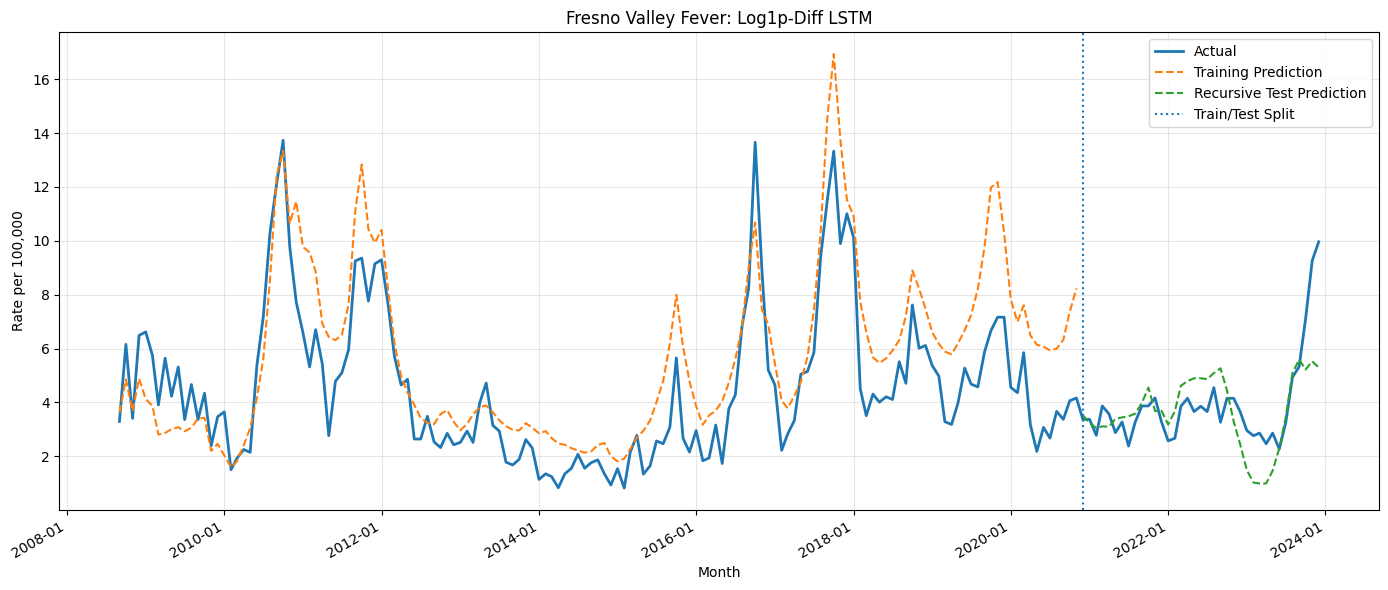

In [9]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=24,
    train_frac=0.80,
    hidden_size=16,
    num_layers=1,
    weight_decay=1e-5,
    dropout=0.4,
    epochs=400,
    learning_rate=0.001,
    log_transform_target=False,
    log1p_diff_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: Log1p-Diff LSTM"
    )
)

X_train shape: torch.Size([148, 24, 5])
X_test shape: torch.Size([37, 24, 5])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.962789
Epoch [80/400] Loss: 0.952224
Epoch [120/400] Loss: 0.927769
Epoch [160/400] Loss: 0.730691
Epoch [200/400] Loss: 0.569465
Epoch [240/400] Loss: 0.507081
Epoch [280/400] Loss: 0.462844
Epoch [320/400] Loss: 0.445687
Epoch [360/400] Loss: 0.443759
Epoch [400/400] Loss: 0.422525

Training RMSE: 0.9410
Training MAE:  0.7096
Training R²:   0.8847

Test RMSE: 0.9616
Test MAE:  0.7178
Test R²:   0.6562


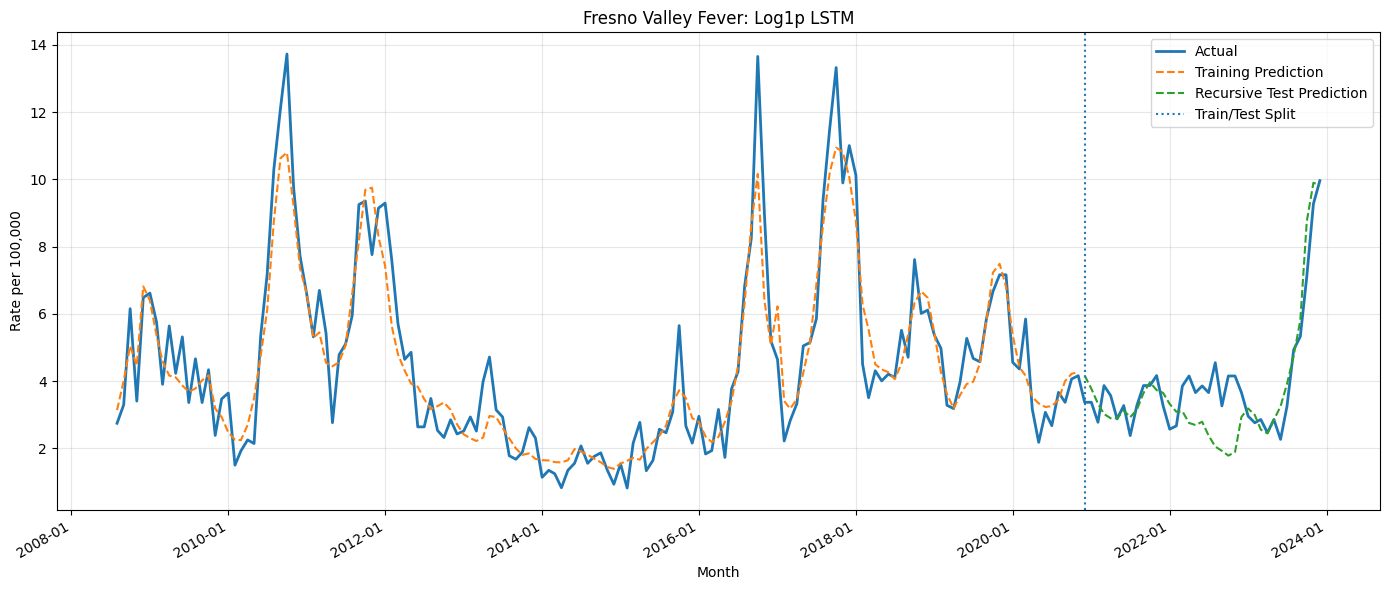

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=24,
    train_frac=0.80,
    hidden_size=16,
    num_layers=1,
    weight_decay=1e-5,
    dropout=0.4,
    epochs=400,
    learning_rate=0.001,
    log_transform_target=True,
    log1p_diff_target=False,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title="Fresno Valley Fever: Log1p LSTM"
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/200] Loss: 0.940760
Epoch [80/200] Loss: 0.609513
Epoch [120/200] Loss: 0.413469
Epoch [160/200] Loss: 0.332670
Epoch [200/200] Loss: 0.271077

Original-scale RMSE: 2.0726
Original-scale MAE:  1.6355
Original-scale R²:   -0.7205


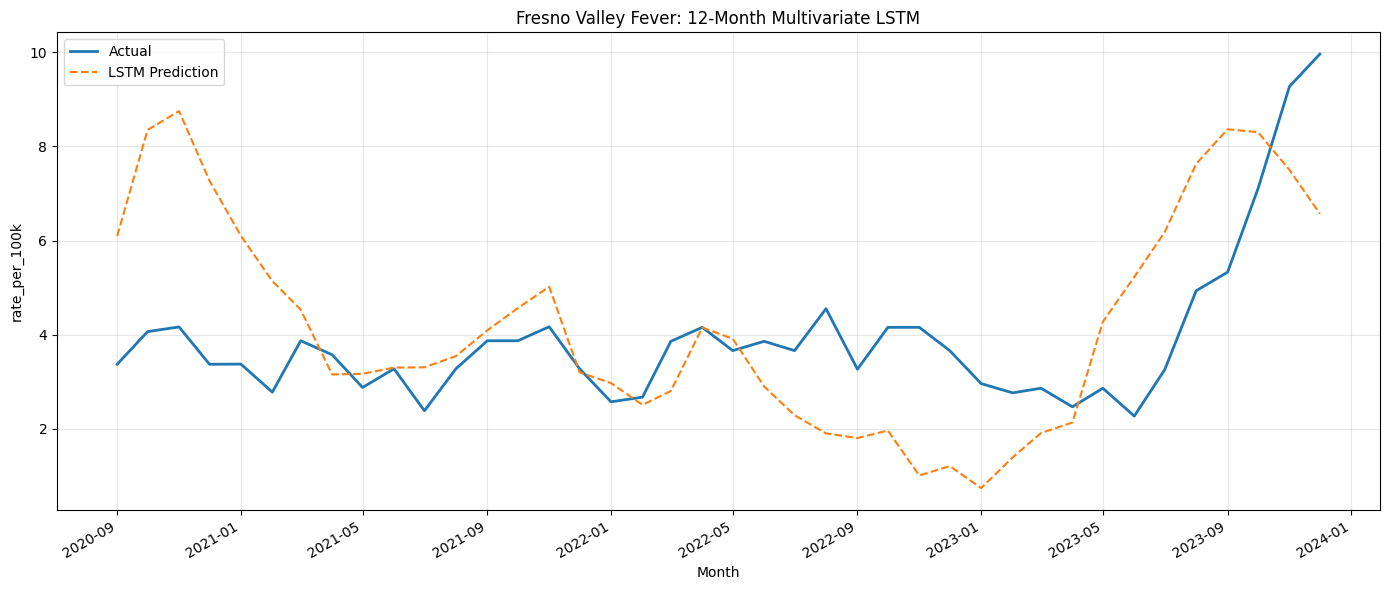

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=32,
    num_layers=2,
    weight_decay=0.00001,
    dropout=0.0,
    epochs=200,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/100] Loss: 0.940760
Epoch [80/100] Loss: 0.609513

Original-scale RMSE: 2.2268
Original-scale MAE:  1.7192
Original-scale R²:   -0.9860


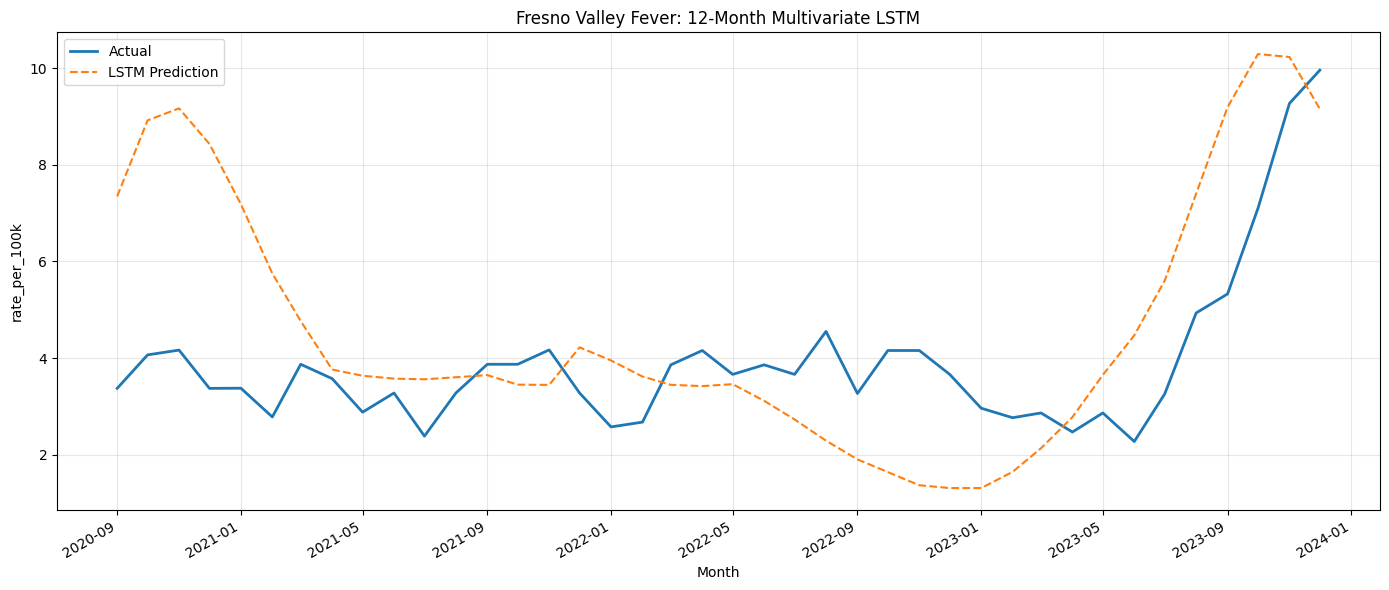

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=32,
    num_layers=2,
    weight_decay=0.00001,
    dropout=0.0,
    epochs=100,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/140] Loss: 0.973807
Epoch [80/140] Loss: 0.752687
Epoch [120/140] Loss: 0.575867

Original-scale RMSE: 2.1303
Original-scale MAE:  1.6671
Original-scale R²:   -0.8176


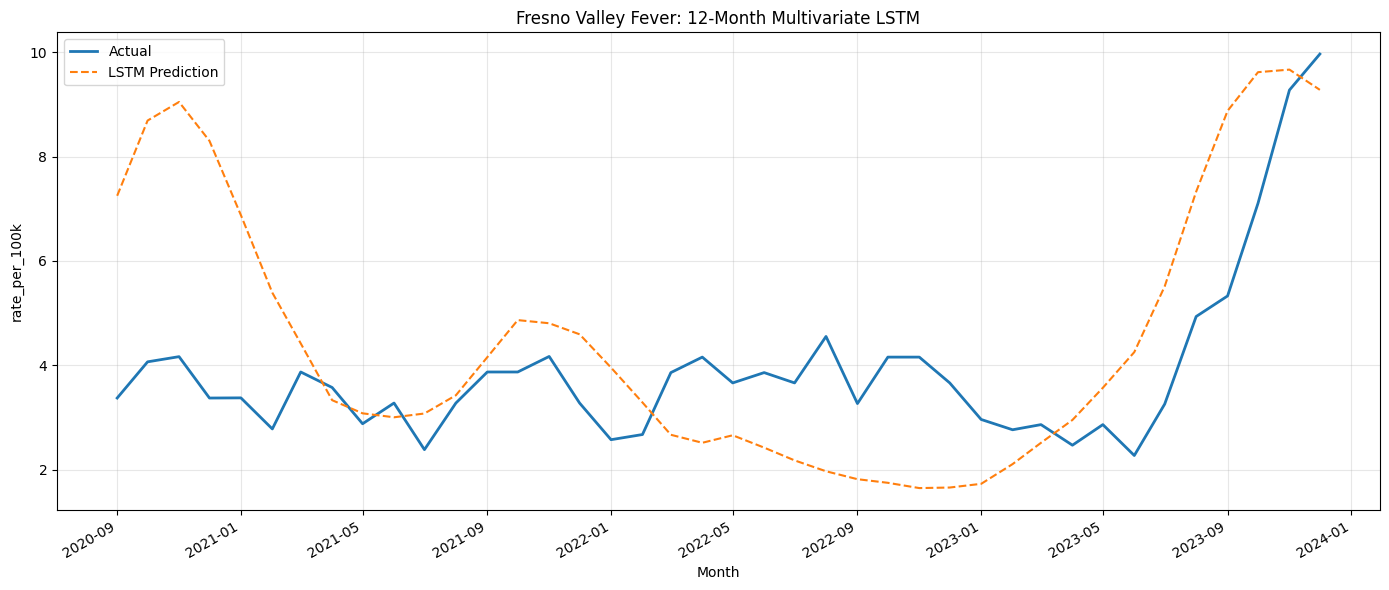

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=16,
    num_layers=2,
    weight_decay=0.00001,
    dropout=0.0,
    epochs=140,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/140] Loss: 0.990490
Epoch [80/140] Loss: 0.836562
Epoch [120/140] Loss: 0.688298

Original-scale RMSE: 2.1462
Original-scale MAE:  1.6216
Original-scale R²:   -0.8448


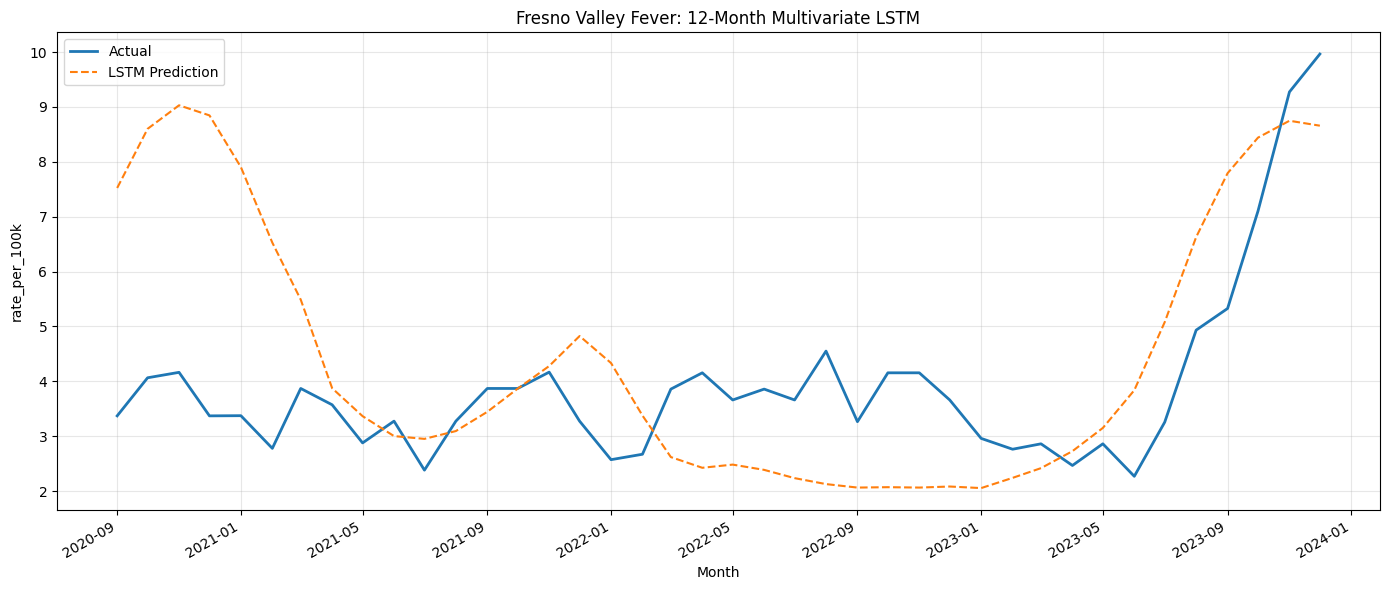

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=16,
    num_layers=2,
    dropout=0.4,
    epochs=140,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/140] Loss: 0.959338
Epoch [80/140] Loss: 0.769569
Epoch [120/140] Loss: 0.587214

Original-scale RMSE: 2.0040
Original-scale MAE:  1.5919
Original-scale R²:   -0.6085


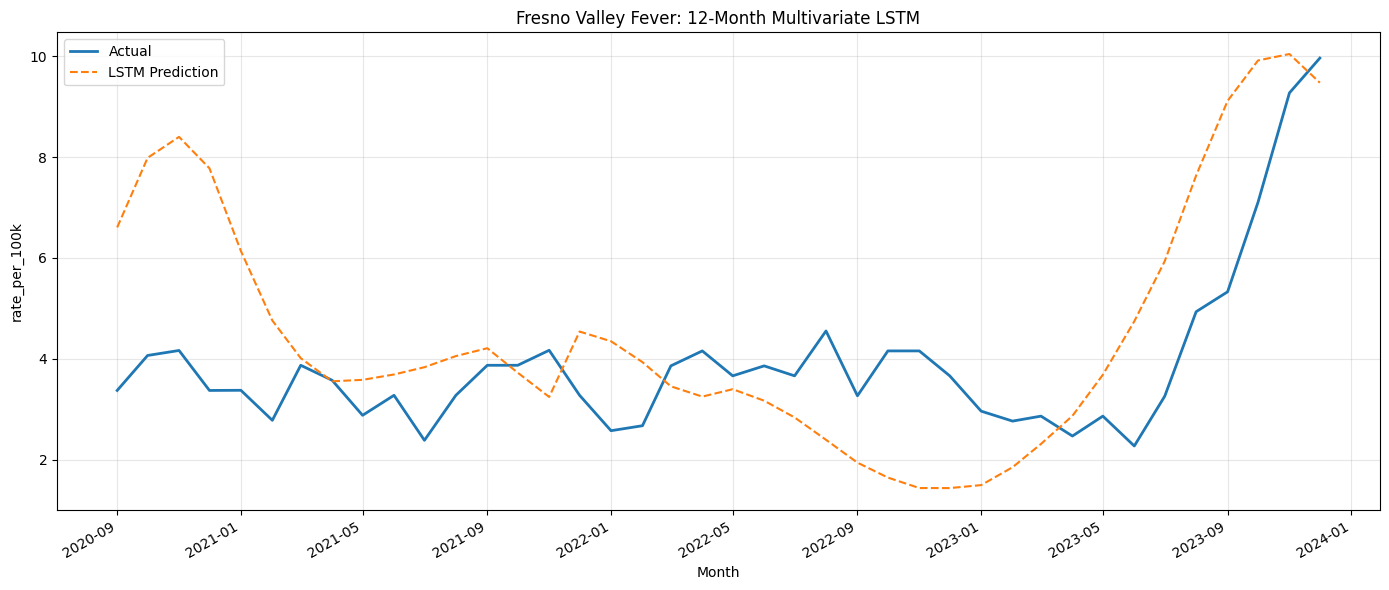

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=32,
    num_layers=2,
    weight_decay=0.00001,
    dropout=0.4,
    epochs=140,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

X_train shape: torch.Size([157, 12, 5])
X_test shape: torch.Size([40, 12, 5])
Training target dates: 2007-08-01T00:00:00.000000000 through 2020-08-01T00:00:00.000000000
Testing target dates: 2020-09-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/200] Loss: 0.979536
Epoch [80/200] Loss: 0.950661
Epoch [120/200] Loss: 0.915022
Epoch [160/200] Loss: 0.744230
Epoch [200/200] Loss: 0.590505

Original-scale RMSE: 2.3831
Original-scale MAE:  1.7873
Original-scale R²:   -1.2746


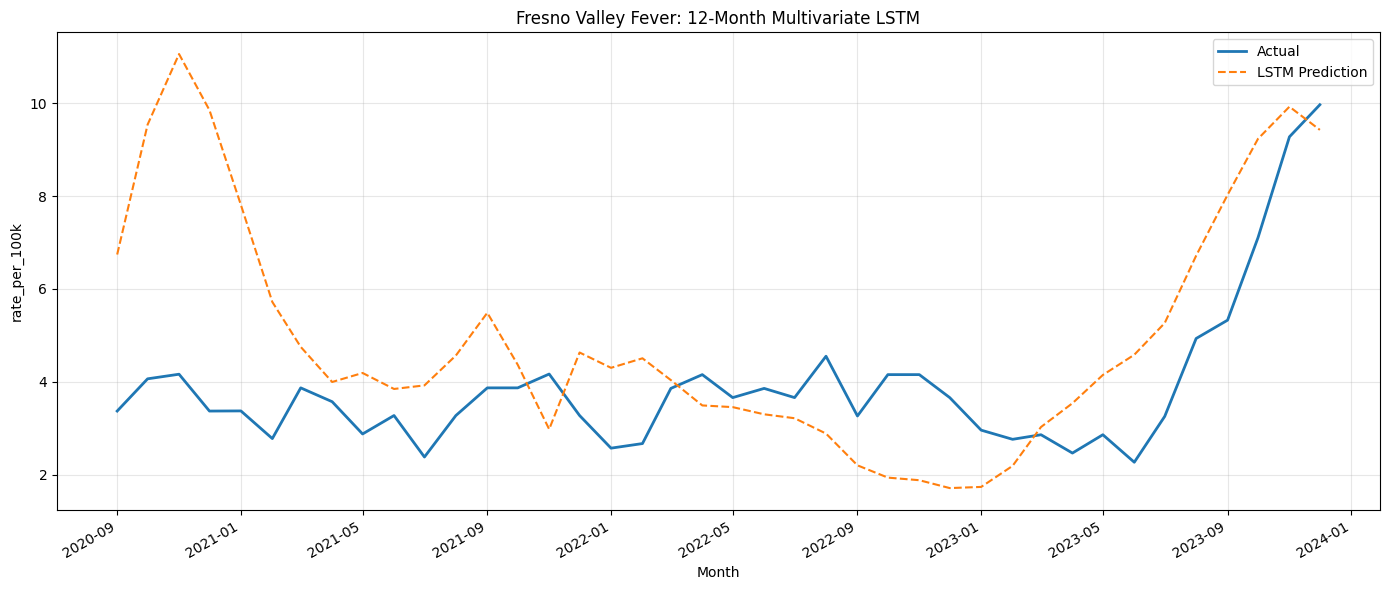

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=12,
    train_frac=0.80,
    hidden_size=16,
    num_layers=1,
    weight_decay=1e-5,
    dropout=0.4,
    epochs=200,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

In [ ]:
fresno_df['log1p_windeventcount'] = np.log1p(fresno_df['windeventcount'])
fresno_df['log1p_fungicide_lbs_prd_used'] = np.log1p(fresno_df['fungicide_lbs_prd_used'])

In [ ]:
fresno_features = [
    "log1p_windeventcount",
    "log1p_fungicide_lbs_prd_used",
    "AQI_PM10",
    "Avg Soil Temp (F)",
    "Wind Run (miles)"
]

X_train shape: torch.Size([148, 24, 5])
X_test shape: torch.Size([37, 24, 5])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.962228
Epoch [80/400] Loss: 0.956992
Epoch [120/400] Loss: 0.953581
Epoch [160/400] Loss: 0.940164
Epoch [200/400] Loss: 0.871683
Epoch [240/400] Loss: 0.653880
Epoch [280/400] Loss: 0.588991
Epoch [320/400] Loss: 0.513180
Epoch [360/400] Loss: 0.509423
Epoch [400/400] Loss: 0.497272

Original-scale RMSE: 1.1494
Original-scale MAE:  0.9462
Original-scale R²:   0.5087


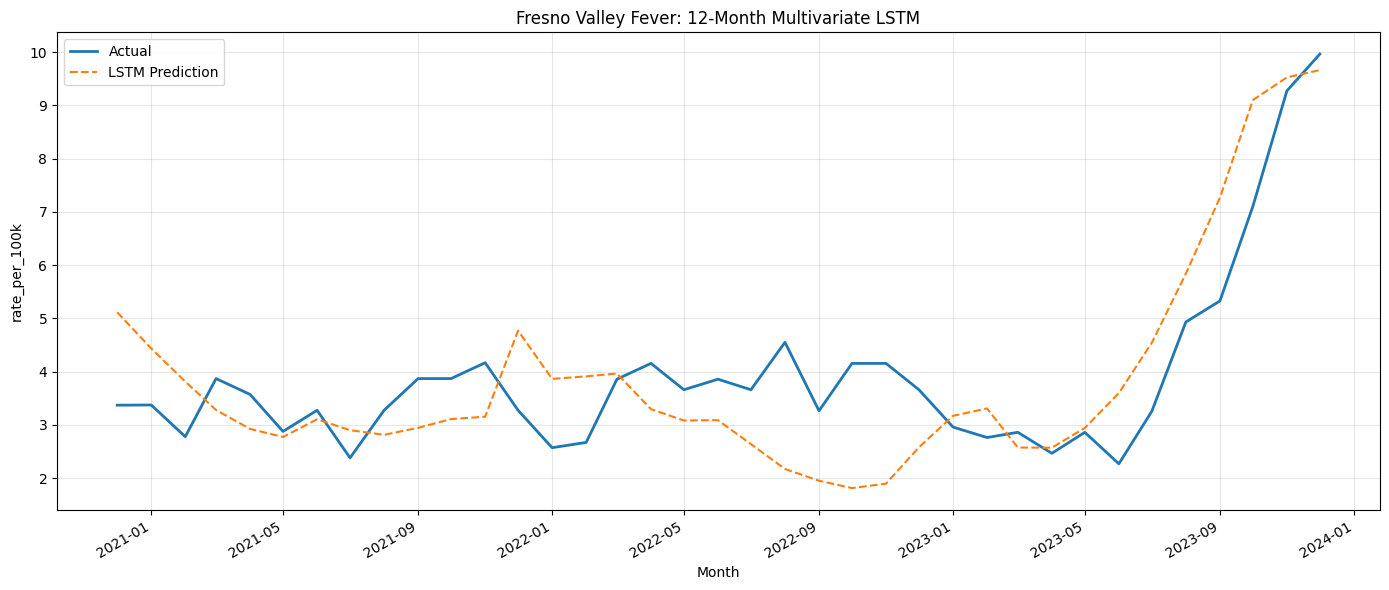

In [ ]:
fresno_lstm_results = train_lstm_forecast(
    df=fresno_df,
    target_col="rate_per_100k",
    feature_cols=fresno_features,
    date_col="Year-Month",
    lookback=24,
    train_frac=0.8,
    hidden_size=16,
    num_layers=1,
    weight_decay=1e-3,
    dropout=0.6,
    epochs=400,
    learning_rate=0.001,
    log_transform_target=True,
    include_target_as_feature=False,
    seed=42,
    verbose=True,
    plot=True,
    title=(
        "Fresno Valley Fever: "
        "12-Month Multivariate LSTM"
    )
)

# run on all counties

In [ ]:
features_by_county = {
    "Fresno": [
        "windeventcount",
        "fungicide_lbs_prd_used",
        "AQI_PM10",
        "Avg Soil Temp (F)",
        "Wind Run (miles)"
    ],
    "Kern": [
        "Avg Rel Hum (%)",
        "fungicide_lbs_prd_used",
        "Avg Soil Temp (F)"
    ],
    "Los Angeles": [
        "Avg Wind Speed (mph)",
        "Precipitation",
        "AQI_PM10"
    ],
    "Orange": [
        "Avg Soil Temp (F)",
        "rodent_lbs_prd_used",
        "FIRE_Acres_Burned",
        "windeventcount"
    ],
    "San Diego": [
        "windeventcount",
        "fungicide_lbs_prd_used",
        "Avg Soil Temp (F)",
        "AQI_PM10"
    ],
    "San Luis Obispo": [
        "fungicide_lbs_prd_used",
        "Avg Soil Temp (F)",
        "Avg Rel Hum (%)",
        "windeventcount"
    ],
    "Tulare": [
        "Avg Soil Temp (F)",
        "Precipitation",
        "windeventcount",
        "Avg Wind Speed (mph)"
    ],
    "Ventura": [
        "AQI_PM10",
        "FIRE_Acres_Burned",
        "Avg Rel Hum (%)"
    ]
}


Running Fresno...
X_train shape: torch.Size([148, 24, 5])
X_test shape: torch.Size([37, 24, 5])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.962789
Epoch [80/400] Loss: 0.952224
Epoch [120/400] Loss: 0.927769
Epoch [160/400] Loss: 0.730691
Epoch [200/400] Loss: 0.569465
Epoch [240/400] Loss: 0.507081
Epoch [280/400] Loss: 0.462844
Epoch [320/400] Loss: 0.445687
Epoch [360/400] Loss: 0.443759
Epoch [400/400] Loss: 0.422525

Original-scale RMSE: 0.9616
Original-scale MAE:  0.7178
Original-scale R²:   0.6562


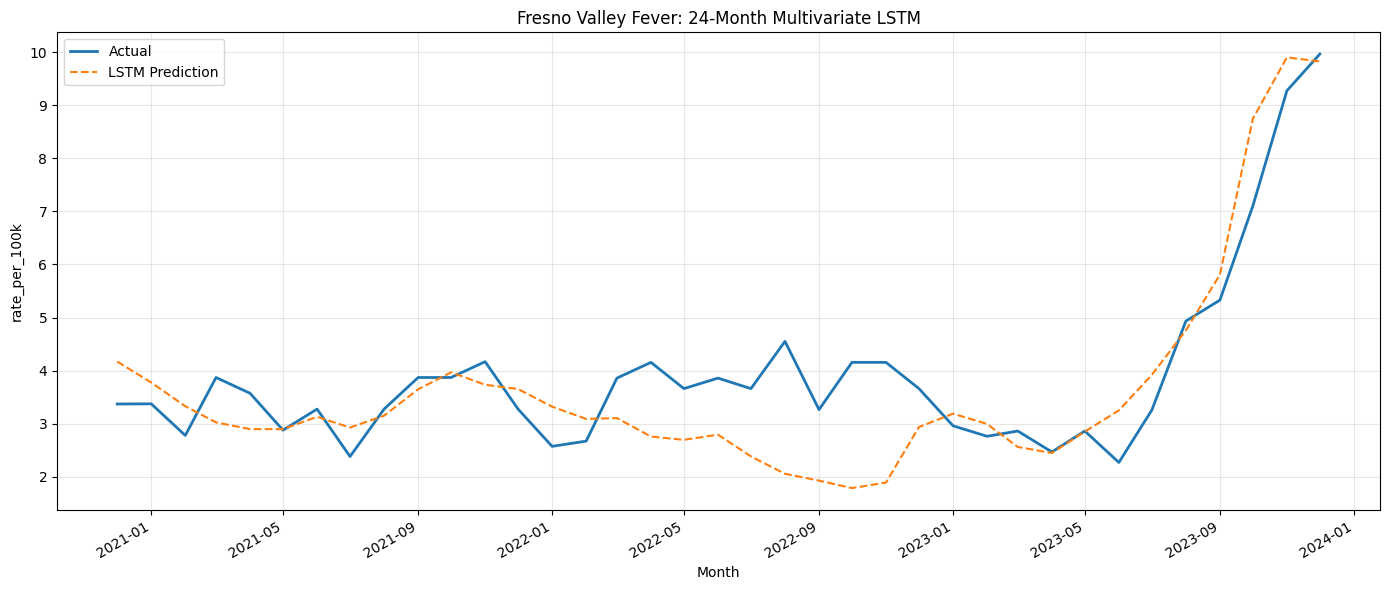


Running Kern...
X_train shape: torch.Size([148, 24, 3])
X_test shape: torch.Size([37, 24, 3])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 1.039317
Epoch [80/400] Loss: 0.996864
Epoch [120/400] Loss: 0.882820
Epoch [160/400] Loss: 0.693847
Epoch [200/400] Loss: 0.582669
Epoch [240/400] Loss: 0.562512
Epoch [280/400] Loss: 0.501336
Epoch [320/400] Loss: 0.530326
Epoch [360/400] Loss: 0.525119
Epoch [400/400] Loss: 0.505892

Original-scale RMSE: 17.8337
Original-scale MAE:  15.8231
Original-scale R²:   -4.4246


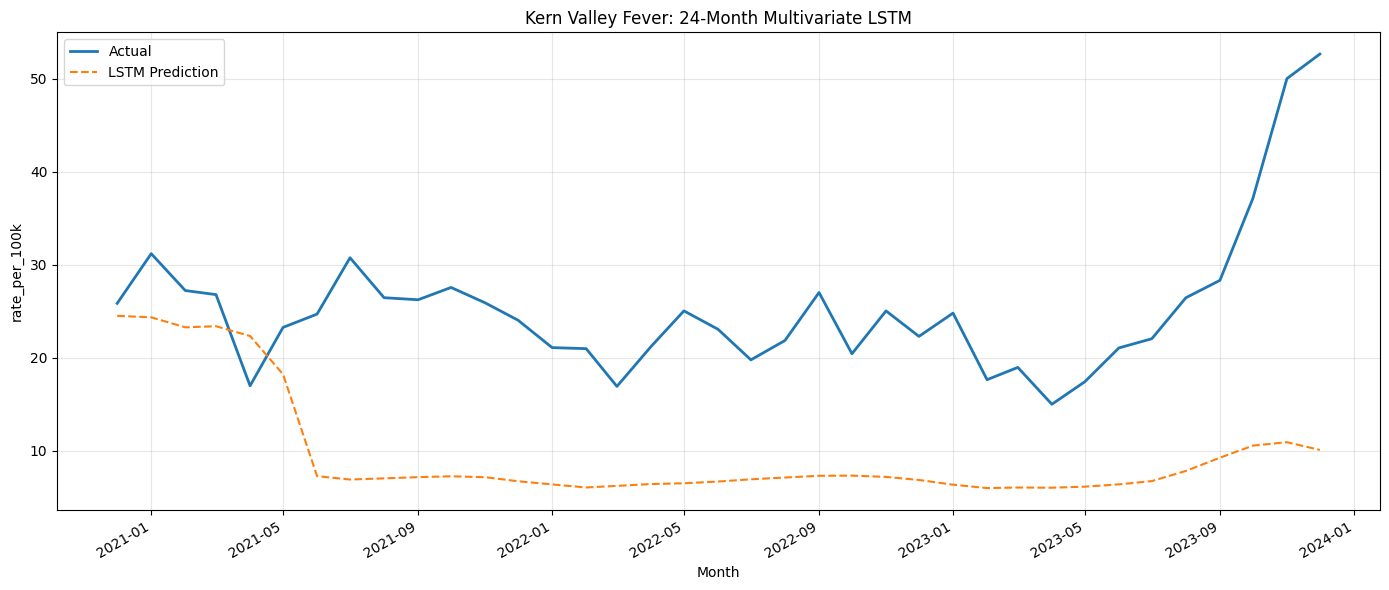


Running Los Angeles...
X_train shape: torch.Size([148, 24, 3])
X_test shape: torch.Size([37, 24, 3])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.965518
Epoch [80/400] Loss: 0.819427
Epoch [120/400] Loss: 0.550705
Epoch [160/400] Loss: 0.456333
Epoch [200/400] Loss: 0.441987
Epoch [240/400] Loss: 0.440286
Epoch [280/400] Loss: 0.424964
Epoch [320/400] Loss: 0.406175
Epoch [360/400] Loss: 0.414169
Epoch [400/400] Loss: 0.379290

Original-scale RMSE: 0.6804
Original-scale MAE:  0.5580
Original-scale R²:   -14.7174


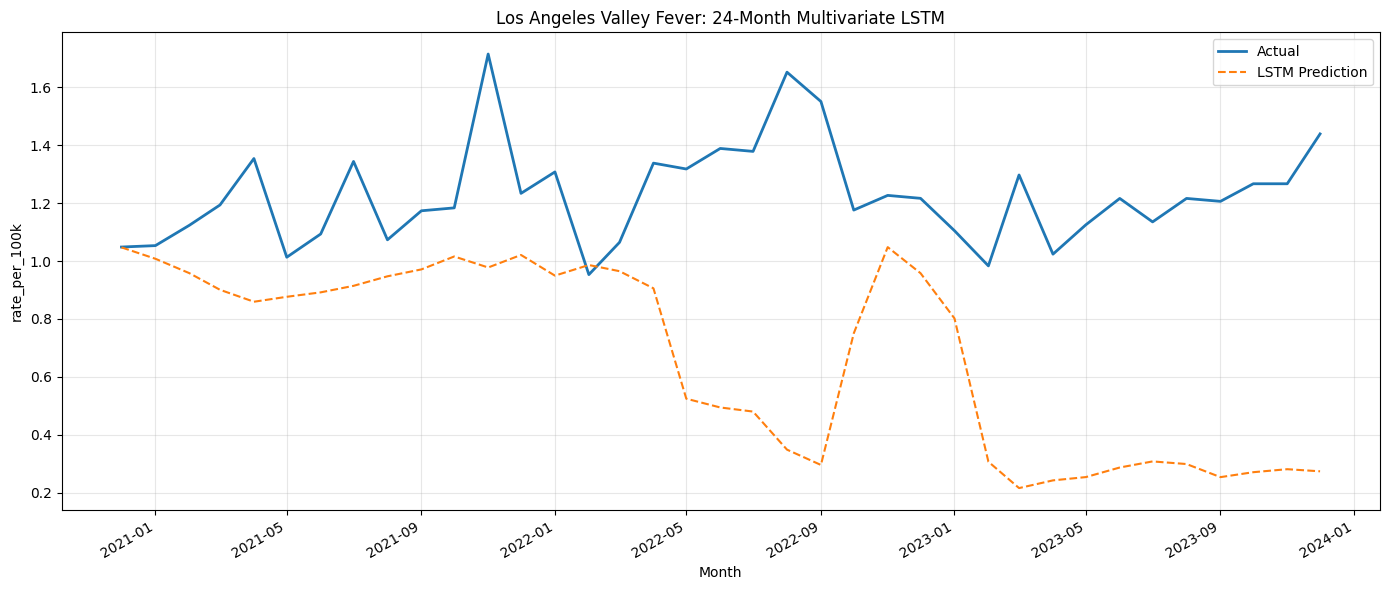


Running Orange...
X_train shape: torch.Size([148, 24, 4])
X_test shape: torch.Size([37, 24, 4])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.940438
Epoch [80/400] Loss: 0.737979
Epoch [120/400] Loss: 0.660760
Epoch [160/400] Loss: 0.616258
Epoch [200/400] Loss: 0.574938
Epoch [240/400] Loss: 0.545758
Epoch [280/400] Loss: 0.574600
Epoch [320/400] Loss: 0.514081
Epoch [360/400] Loss: 0.551662
Epoch [400/400] Loss: 0.525057

Original-scale RMSE: 0.3299
Original-scale MAE:  0.2705
Original-scale R²:   -2.6861


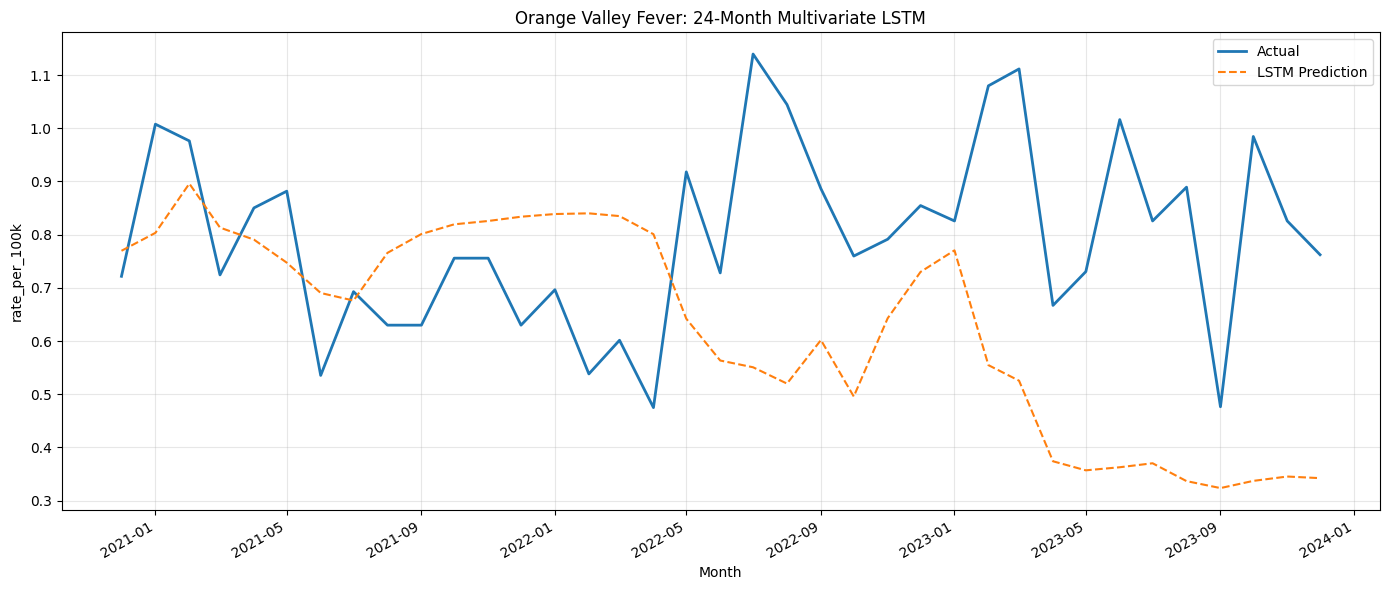


Running San Diego...
X_train shape: torch.Size([148, 24, 4])
X_test shape: torch.Size([37, 24, 4])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.967552
Epoch [80/400] Loss: 0.810755
Epoch [120/400] Loss: 0.571519
Epoch [160/400] Loss: 0.514784
Epoch [200/400] Loss: 0.504472
Epoch [240/400] Loss: 0.482553
Epoch [280/400] Loss: 0.483325
Epoch [320/400] Loss: 0.468921
Epoch [360/400] Loss: 0.477496
Epoch [400/400] Loss: 0.478089

Original-scale RMSE: 0.8031
Original-scale MAE:  0.7750
Original-scale R²:   -13.5693


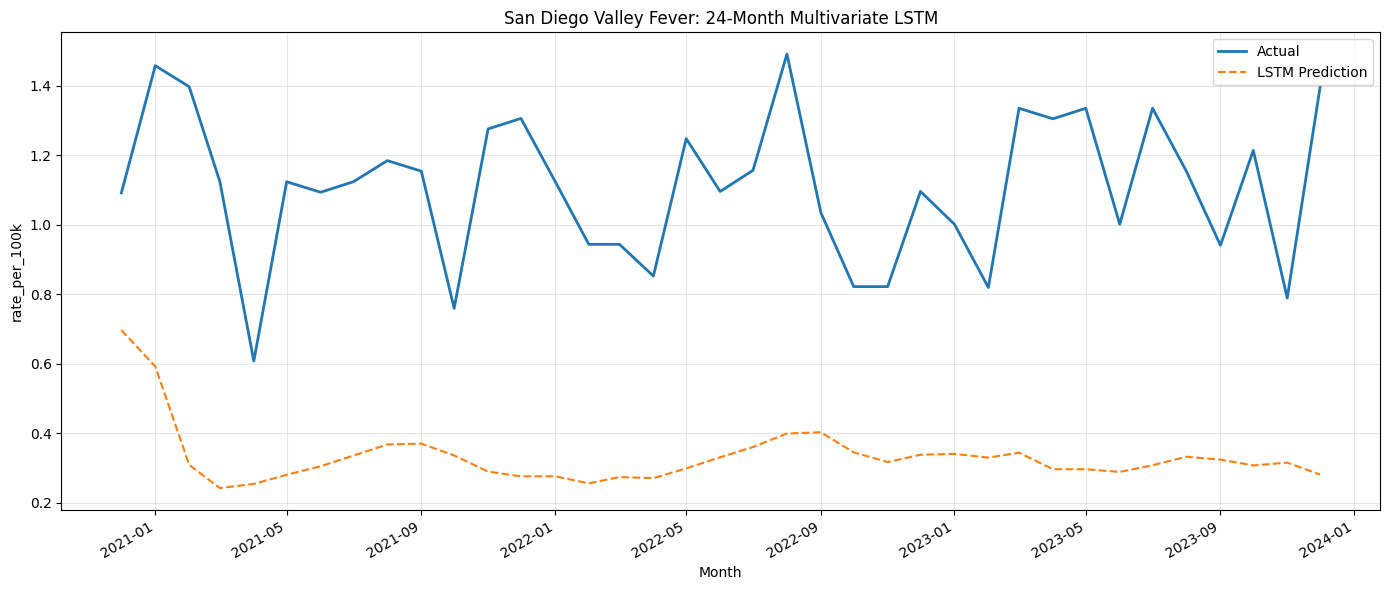


Running San Luis Obispo...
X_train shape: torch.Size([148, 24, 4])
X_test shape: torch.Size([37, 24, 4])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 0.955646
Epoch [80/400] Loss: 0.766227
Epoch [120/400] Loss: 0.644204
Epoch [160/400] Loss: 0.572721
Epoch [200/400] Loss: 0.503575
Epoch [240/400] Loss: 0.517435
Epoch [280/400] Loss: 0.501364
Epoch [320/400] Loss: 0.476592
Epoch [360/400] Loss: 0.467318
Epoch [400/400] Loss: 0.459787

Original-scale RMSE: 4.5238
Original-scale MAE:  3.3792
Original-scale R²:   0.0769


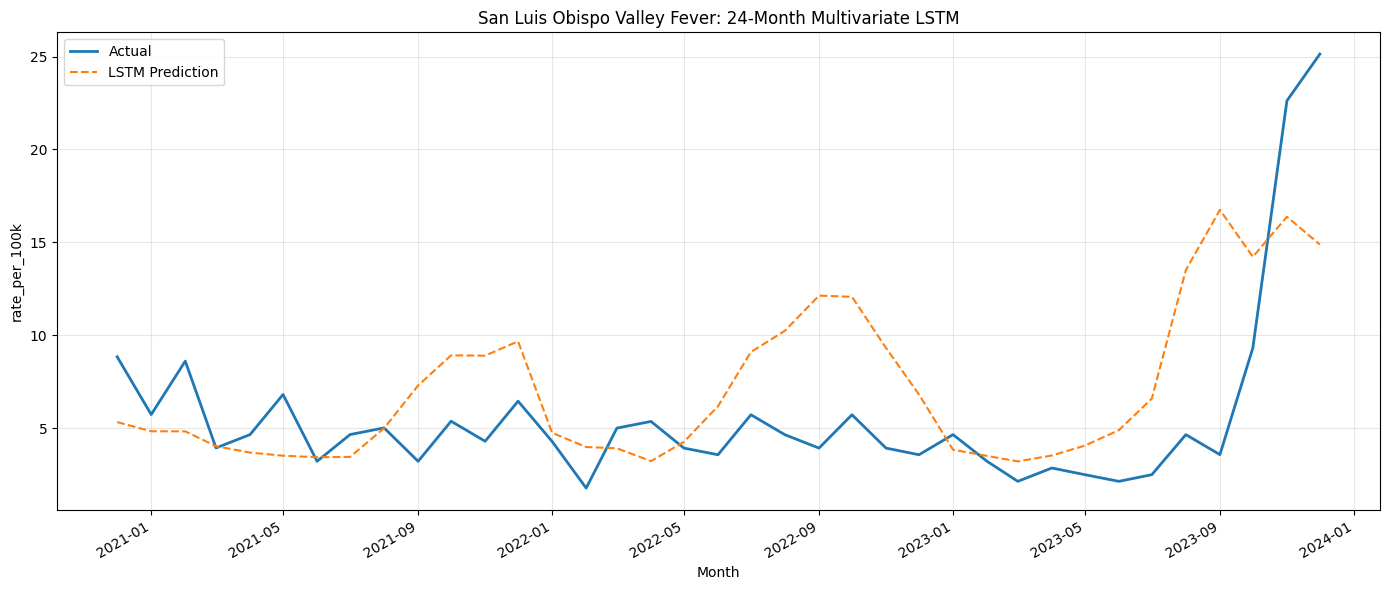


Running Tulare...
X_train shape: torch.Size([148, 24, 4])
X_test shape: torch.Size([37, 24, 4])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 1.011265
Epoch [80/400] Loss: 0.954350
Epoch [120/400] Loss: 0.828650
Epoch [160/400] Loss: 0.693697
Epoch [200/400] Loss: 0.677458
Epoch [240/400] Loss: 0.648443
Epoch [280/400] Loss: 0.611392
Epoch [320/400] Loss: 0.596794
Epoch [360/400] Loss: 0.574284
Epoch [400/400] Loss: 0.508447

Original-scale RMSE: 3.3888
Original-scale MAE:  2.9658
Original-scale R²:   -0.1484


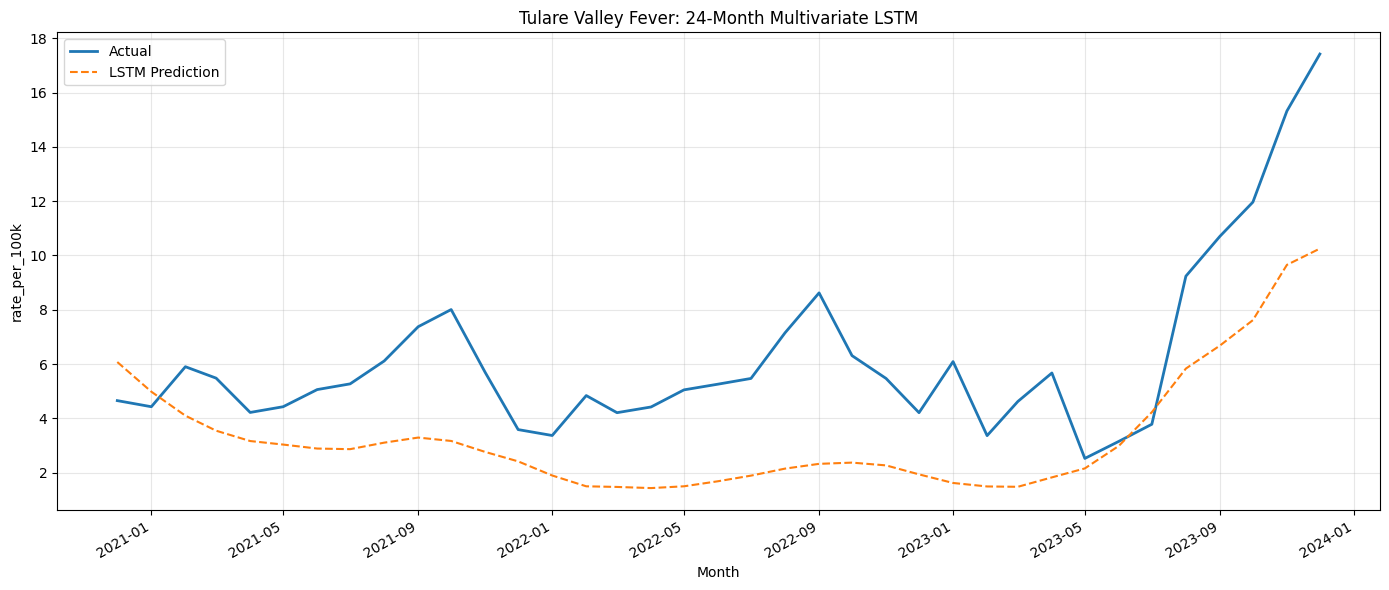


Running Ventura...
X_train shape: torch.Size([148, 24, 3])
X_test shape: torch.Size([37, 24, 3])
Training target dates: 2008-08-01T00:00:00.000000000 through 2020-11-01T00:00:00.000000000
Testing target dates: 2020-12-01T00:00:00.000000000 through 2023-12-01T00:00:00.000000000
Epoch [40/400] Loss: 1.007486
Epoch [80/400] Loss: 0.991031
Epoch [120/400] Loss: 0.865752
Epoch [160/400] Loss: 0.530146
Epoch [200/400] Loss: 0.423039
Epoch [240/400] Loss: 0.477380
Epoch [280/400] Loss: 0.477678
Epoch [320/400] Loss: 0.464007
Epoch [360/400] Loss: 0.487956
Epoch [400/400] Loss: 0.455772

Original-scale RMSE: 2.3718
Original-scale MAE:  2.1257
Original-scale R²:   -3.3368


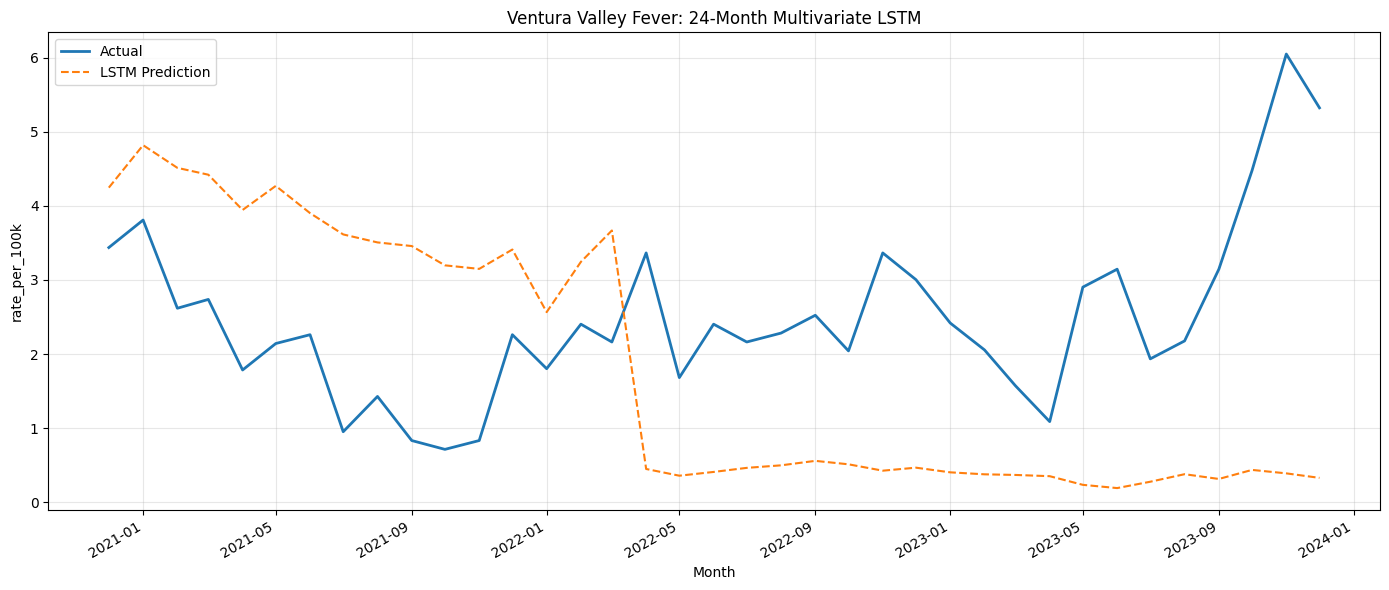

In [ ]:
all_county_lstm_results = {}
all_county_lstm_metrics = []

for county, feature_cols in features_by_county.items():

    print(f"\nRunning {county}...")

    county_df = aggregated_data_trimmed[
        aggregated_data_trimmed["County"] == county
    ].copy().sort_values("Year-Month").reset_index(drop=True)

    county_results = train_lstm_forecast(
        df=county_df,
        target_col="rate_per_100k",
        feature_cols=feature_cols,
        date_col="Year-Month",
        lookback=24,
        train_frac=0.80,
        hidden_size=16,
        num_layers=1,
        weight_decay=1e-5,
        dropout=0.4,
        epochs=400,
        learning_rate=0.001,
        log_transform_target=True,
        include_target_as_feature=False,
        seed=42,
        verbose=True,
        plot=True,
        title=f"{county} Valley Fever: 24-Month Multivariate LSTM"
    )

    all_county_lstm_results[county] = county_results

    all_county_lstm_metrics.append({
        "County": county,
        "RMSE": county_results["rmse"],
        "MAE": county_results["mae"],
        "R2": county_results["r2"],
        "Lookback": county_results["lookback"],
        "Number_Features": len(feature_cols),
        "Features": feature_cols,
        "X_Train_Shape": county_results["X_train_shape"],
        "X_Test_Shape": county_results["X_test_shape"]
    })

In [ ]:
all_county_lstm_metrics_df = pd.DataFrame(all_county_lstm_metrics)

display(
    all_county_lstm_metrics_df.sort_values("RMSE")
)

,County,RMSE,MAE,R2,Lookback,Number_Features,Features,X_Train_Shape,X_Test_Shape
3,Orange,0.329908,0.270496,-2.686124,24,4,"[Avg Soil Temp (F), rodent_lbs_prd_used, FIRE_...","(148, 24, 4)","(37, 24, 4)"
2,Los Angeles,0.680399,0.558049,-14.717405,24,3,"[Avg Wind Speed (mph), Precipitation, AQI_PM10]","(148, 24, 3)","(37, 24, 3)"
4,San Diego,0.803054,0.774973,-13.569347,24,4,"[windeventcount, fungicide_lbs_prd_used, Avg S...","(148, 24, 4)","(37, 24, 4)"
0,Fresno,0.961560,0.717764,0.656163,24,5,"[windeventcount, fungicide_lbs_prd_used, AQI_P...","(148, 24, 5)","(37, 24, 5)"
7,Ventura,2.371753,2.125685,-3.336793,24,3,"[AQI_PM10, FIRE_Acres_Burned, Avg Rel Hum (%)]","(148, 24, 3)","(37, 24, 3)"
6,Tulare,3.388776,2.965771,-0.148409,24,4,"[Avg Soil Temp (F), Precipitation, windeventco...","(148, 24, 4)","(37, 24, 4)"
5,San Luis Obispo,4.523785,3.379185,0.076936,24,4,"[fungicide_lbs_prd_used, Avg Soil Temp (F), Av...","(148, 24, 4)","(37, 24, 4)"
1,Kern,17.833722,15.823106,-4.424551,24,3,"[Avg Rel Hum (%), fungicide_lbs_prd_used, Avg ...","(148, 24, 3)","(37, 24, 3)"


In [ ]:
all_county_lstm_predictions = []

for county, county_results in all_county_lstm_results.items():

    county_predictions = county_results["results"].copy()
    county_predictions["County"] = county

    all_county_lstm_predictions.append(county_predictions)

all_county_lstm_predictions_df = pd.concat(
    all_county_lstm_predictions,
    ignore_index=True
)

In [ ]:
display(all_county_lstm_predictions_df)

,Year-Month,Actual,Predicted,County
0,2020-12-01,3.370832,4.170192,Fresno
1,2021-01-01,3.373933,3.775573,Fresno
2,2021-02-01,2.778533,3.328829,Fresno
3,2021-03-01,3.870100,3.023774,Fresno
4,2021-04-01,3.572400,2.897649,Fresno
...,...,...,...,...
291,2023-08-01,2.177068,0.378935,Ventura
292,2023-09-01,3.144654,0.314737,Ventura
293,2023-10-01,4.475085,0.436827,Ventura
294,2023-11-01,6.047412,0.390223,Ventura


In [ ]:
fresno_predictions = all_county_lstm_predictions_df[all_county_lstm_predictions_df['County'] == 'Fresno']
fresno_predictions

,Year-Month,Actual,Predicted,County
0,2020-12-01,3.370832,4.170192,Fresno
1,2021-01-01,3.373933,3.775573,Fresno
2,2021-02-01,2.778533,3.328829,Fresno
3,2021-03-01,3.870100,3.023774,Fresno
4,2021-04-01,3.572400,2.897649,Fresno
5,2021-05-01,2.877766,2.896439,Fresno
6,2021-06-01,3.274700,3.128920,Fresno
7,2021-07-01,2.381600,2.927976,Fresno
8,2021-08-01,3.274700,3.150628,Fresno
9,2021-09-01,3.870100,3.647488,Fresno


In [ ]:
fresno_predictions.to_csv('fresno_lstm_predictions_using_screened_variables.csv')